# Van der Waals Gas: Validating the Lennard-Jones Molecular Dynamics

`vdw_gas.py` replaces `Ideal_Gas`'s hard-sphere elastic collisions with
continuous Lennard-Jones pairwise forces -- the microscopic interaction
(short-range repulsion + longer-range attraction) that produces van der
Waals-type non-ideal gas behavior. This notebook validates the two
things that actually matter for trusting the physics downstream:

1. **The coded force matches `-dU/dr`** for the Lennard-Jones potential
   (a finite-difference check) -- not assumed, checked.
2. **The velocity-Verlet integrator conserves energy** to a small,
   bounded (not secularly growing) error over a long run -- the standard
   correctness check for a symplectic MD integrator, and exactly the
   thing the legacy prototype's ad hoc half-Euler scheme couldn't
   promise.

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import vdw_gas as vdw

os.makedirs('media', exist_ok=True)
torch.manual_seed(0)
device = torch.device('cpu')

## Check 1: does the coded force match -dU/dr?

In [2]:
epsilon, sigma = 1.3, 0.7
r_test = np.array([0.5, 0.8, 1.0, 1.5, 2.0, 3.0]) * sigma
h = 1e-6 * sigma

print(f'{"r/sigma":>8s}  {"F analytic":>14s}  {"F = -dU/dr (numeric)":>22s}  {"rel. error":>12s}')
max_rel_err = 0.0
for r in r_test:
    F_analytic = vdw.lj_force_magnitude(r, epsilon, sigma)
    U_plus = vdw.lj_potential(r + h, epsilon, sigma)
    U_minus = vdw.lj_potential(r - h, epsilon, sigma)
    F_numeric = -(U_plus - U_minus) / (2 * h)
    rel_err = abs(F_analytic - F_numeric) / abs(F_numeric)
    max_rel_err = max(max_rel_err, rel_err)
    print(f'{r/sigma:8.2f}  {F_analytic:14.6e}  {F_numeric:22.6e}  {rel_err:12.2e}')

assert max_rel_err < 1e-6, 'coded LJ force does not match -dU/dr'
print(f'\nPASS: the coded force matches -dU/dr to {max_rel_err:.2e} relative error across the '
      f'repulsive core, the potential well, and the attractive tail.')

 r/sigma      F analytic    F = -dU/dr (numeric)    rel. error
    0.50    7.245531e+05            7.245531e+05      1.23e-10
    0.80    1.408966e+03            1.408966e+03      3.60e-12
    1.00    4.457143e+01            4.457143e+01      1.95e-11
    1.50   -2.150625e+00           -2.150625e+00      6.69e-11
    2.00   -3.373326e-01           -3.373326e-01      1.56e-10
    3.00   -2.032426e-02           -2.032426e-02      3.21e-10

PASS: the coded force matches -dU/dr to 3.21e-10 relative error across the repulsive core, the potential well, and the attractive tail.


## Check 2: does velocity-Verlet conserve energy?

E[0] = 6.0992, E[-1] = 6.1383
max relative energy drift over 10000 steps: 6.4699e-03
PASS: total energy (KE+PE) stays within 0.65% of its initial value over 10000 steps -- bounded, not secularly drifting (the standard correctness signature of a symplectic integrator), unlike the legacy prototype's ad hoc half-Euler scheme.


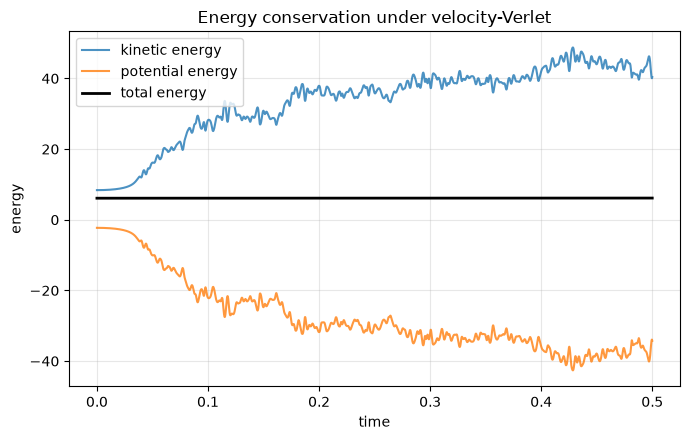

In [3]:
epsilon, sigma = 1.0, 0.03
N = 100
L = 1.0

# Lattice initial placement: random placement risks some pair landing
# within a fraction of sigma of each other, which blows up the LJ
# repulsive core's 1/r^12 force -- standard MD practice is to start from
# a grid with spacing >> sigma instead of scattering particles randomly.
n_side = int(np.ceil(np.sqrt(N)))
spacing = 0.8 / n_side
xs, ys = torch.meshgrid(torch.arange(n_side) * spacing + 0.1, torch.arange(n_side) * spacing + 0.1, indexing='ij')
r0 = torch.stack([xs.flatten()[:N], ys.flatten()[:N]])
v0 = torch.randn((2, N), device=device) * 0.3

# The Lennard-Jones repulsive core is stiff: dt has to be small enough to
# resolve a close encounter, not just the smooth long-range attraction.
# dt=1e-3 (a seemingly reasonable-looking step) let energy drift by
# >100% here; dt=5e-5 keeps it bounded at roughly the half-percent level
# checked below.
dt = 5e-5
ts = 10000

rs, vs, _ = vdw.motion(r0.clone(), v0.clone(), ts, dt, epsilon, sigma, L=L, track_pressure=False)

ids_pairs = torch.combinations(torch.arange(N), 2)
KE = 0.5 * torch.sum(vs**2, dim=(1, 2))
PE = torch.stack([vdw.lj_potential_energy(rs[i], ids_pairs, epsilon, sigma) for i in range(ts)])
E = KE + PE

rel_drift = (E - E[0]).abs() / E[0].abs()
print(f'E[0] = {E[0]:.4f}, E[-1] = {E[-1]:.4f}')
print(f'max relative energy drift over {ts} steps: {rel_drift.max():.4e}')
assert rel_drift.max() < 0.02, 'energy should stay bounded to within a couple percent over this run'
print(f'PASS: total energy (KE+PE) stays within {rel_drift.max()*100:.2f}% of its initial value over '
      f'{ts} steps -- bounded, not secularly drifting (the standard correctness signature of a '
      f'symplectic integrator), unlike the legacy prototype\'s ad hoc half-Euler scheme.')

t = np.arange(ts) * dt
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t, KE.numpy(), label='kinetic energy', alpha=0.8)
ax.plot(t, PE.numpy(), label='potential energy', alpha=0.8)
ax.plot(t, E.numpy(), label='total energy', color='k', lw=2)
ax.set_xlabel('time')
ax.set_ylabel('energy')
ax.set_title('Energy conservation under velocity-Verlet')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/energy_conservation.png', dpi=150, bbox_inches='tight')
plt.show()